In [1]:
# ============================================================
# Cell 1: Import Libraries and Environment Setup
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os

# Configure inline plotting for VS Code/Jupyter
%matplotlib inline
sns.set(style="whitegrid")

# 1. Path Management
# Assuming notebook is in /notebooks and data is in /datasets
data_folder = os.path.join('..', 'datasets')
file_name = 'healthcare-dataset-stroke-data.csv'
local_path = os.path.join(data_folder, file_name)

# 2. Data Loading Logic
if os.path.exists(local_path):
    df = pd.read_csv(local_path)
    print(f"Success: Dataset loaded from: {local_path}")
else:
    print("Warning: Local file not found. Check your directory structure.")

# 3. Initial Inspection
print(f"Dataset Shape: {df.shape}")
df.head()

Success: Dataset loaded from: ..\datasets\healthcare-dataset-stroke-data.csv
Dataset Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [2]:
# ============================================================
# Cell 2: Descriptive Statistics
# ============================================================
print("--- Basic Information ---")
print(df.info())

print("\n--- Numerical Summary ---")
# Provides mean, std, min, max, and quartiles
display(df[['age', 'avg_glucose_level', 'bmi']].describe())

print("\n--- Categorical Summary ---")
# Provides unique counts and most frequent values
display(df.describe(include=['object']))

--- Basic Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None

--- Numerical Summary ---


,age,avg_glucose_level,bmi
count,5110.000000,5110.000000,4909.000000
mean,43.226614,106.147677,28.893237
std,22.612647,45.283560,7.854067
min,0.080000,55.120000,10.300000
25%,25.000000,77.245000,23.500000
50%,45.000000,91.885000,28.100000
75%,61.000000,114.090000,33.100000
max,82.000000,271.740000,97.600000



--- Categorical Summary ---


,gender,ever_married,work_type,Residence_type,smoking_status
count,5110,5110,5110,5110,5110
unique,3,2,5,2,4
top,Female,Yes,Private,Urban,never smoked
freq,2994,3353,2925,2596,1892


--- Missing Value Count ---
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


<Figure size 1000x400 with 0 Axes>

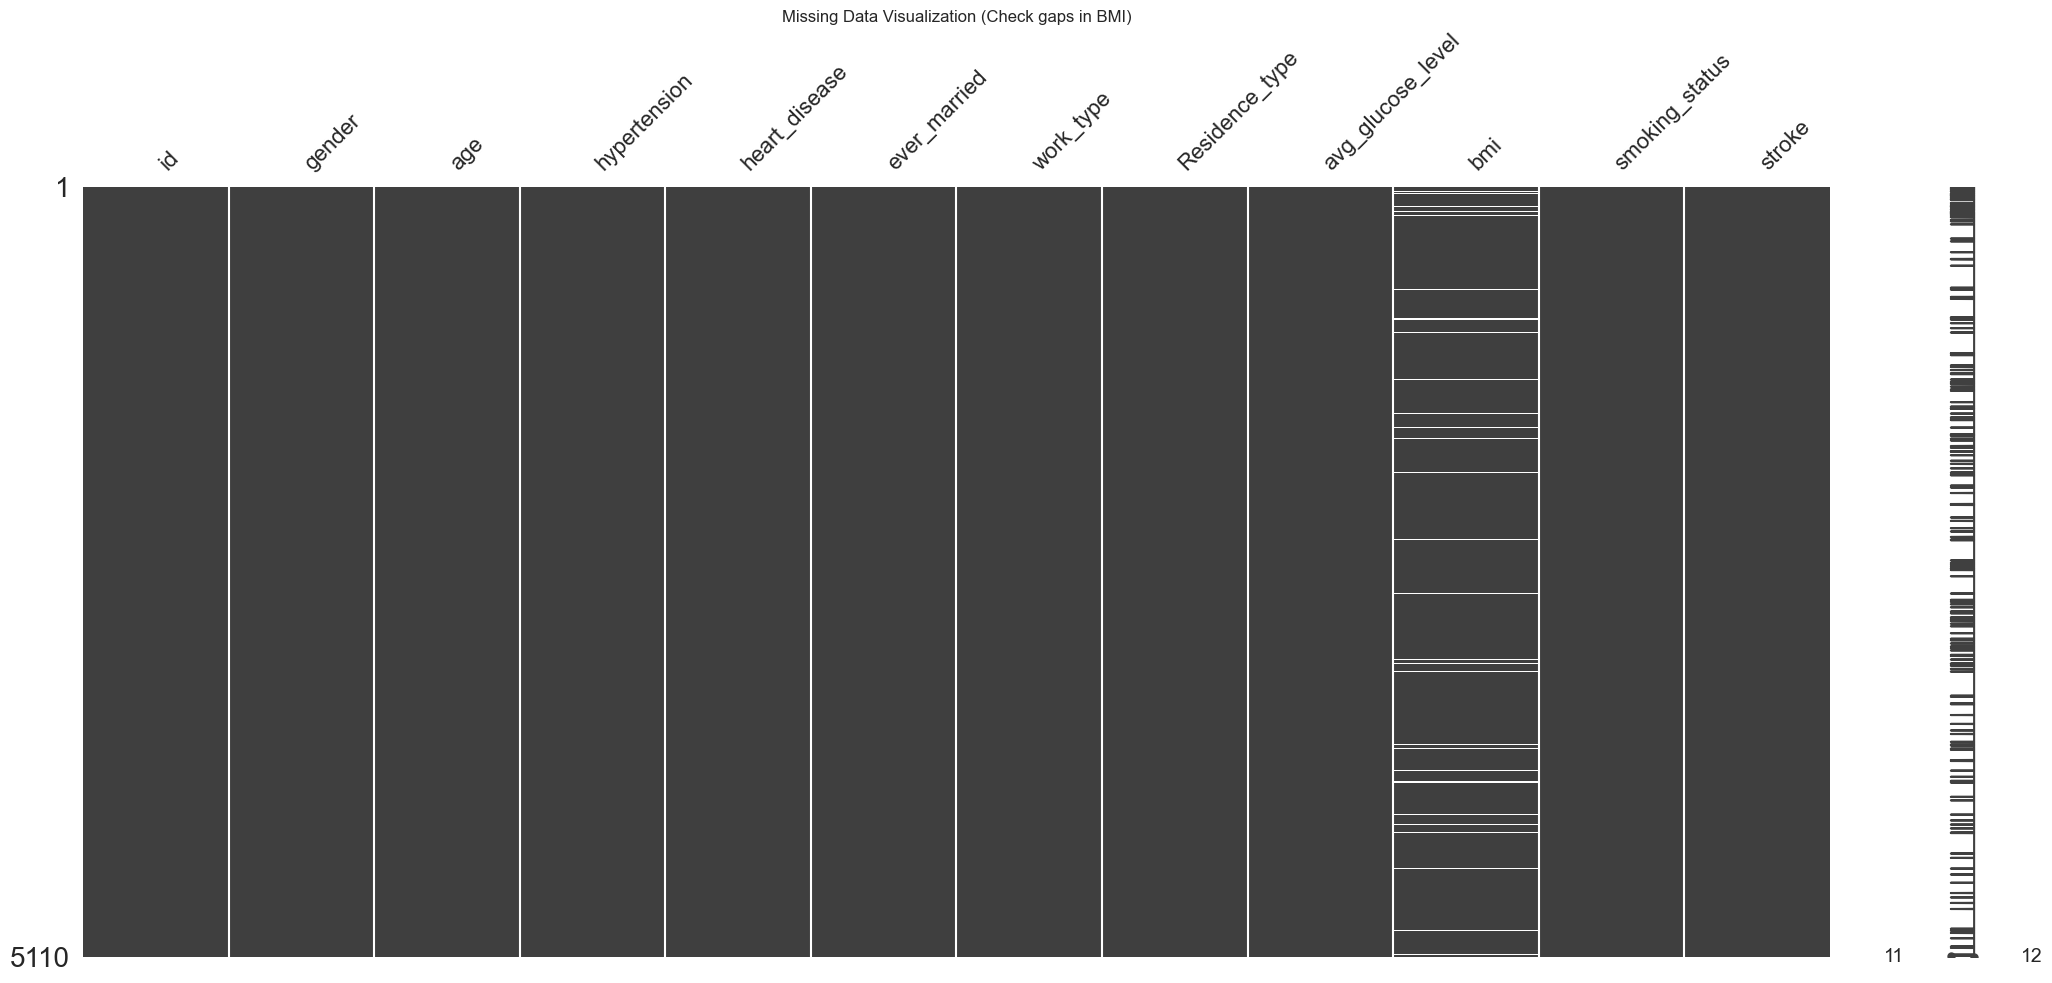

In [3]:
# ============================================================
# Cell 3: Missing Value Analysis
# ============================================================
print("--- Missing Value Count ---")
print(df.isnull().sum())

# Visualizing missing values using missingno matrix
plt.figure(figsize=(10, 4))
msno.matrix(df)
plt.title("Missing Data Visualization (Check gaps in BMI)")
plt.show()

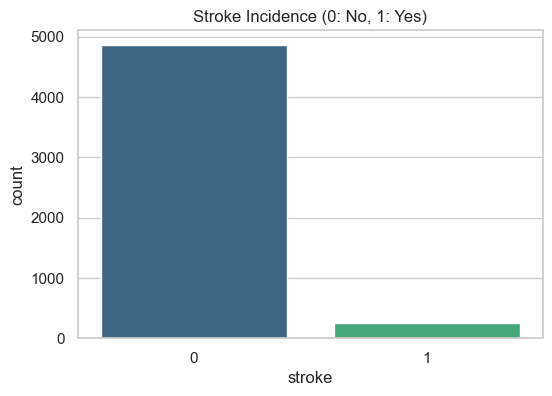

Stroke Incidence Rate: 4.87%
Note: This indicates a significant class imbalance.


In [4]:
# ============================================================
# Cell 4: Target Variable Distribution (Stroke)
# ============================================================
plt.figure(figsize=(6, 4))
# Fixed: Assigned 'x' to 'hue' and set legend=False to avoid FutureWarnings
sns.countplot(x='stroke', data=df, hue='stroke', palette='viridis', legend=False)
plt.title('Stroke Incidence (0: No, 1: Yes)')
plt.show()

# Calculate the imbalance percentage
stroke_pct = df['stroke'].value_counts(normalize=True) * 100
print(f"Stroke Incidence Rate: {stroke_pct[1]:.2f}%")
print("Note: This indicates a significant class imbalance.")

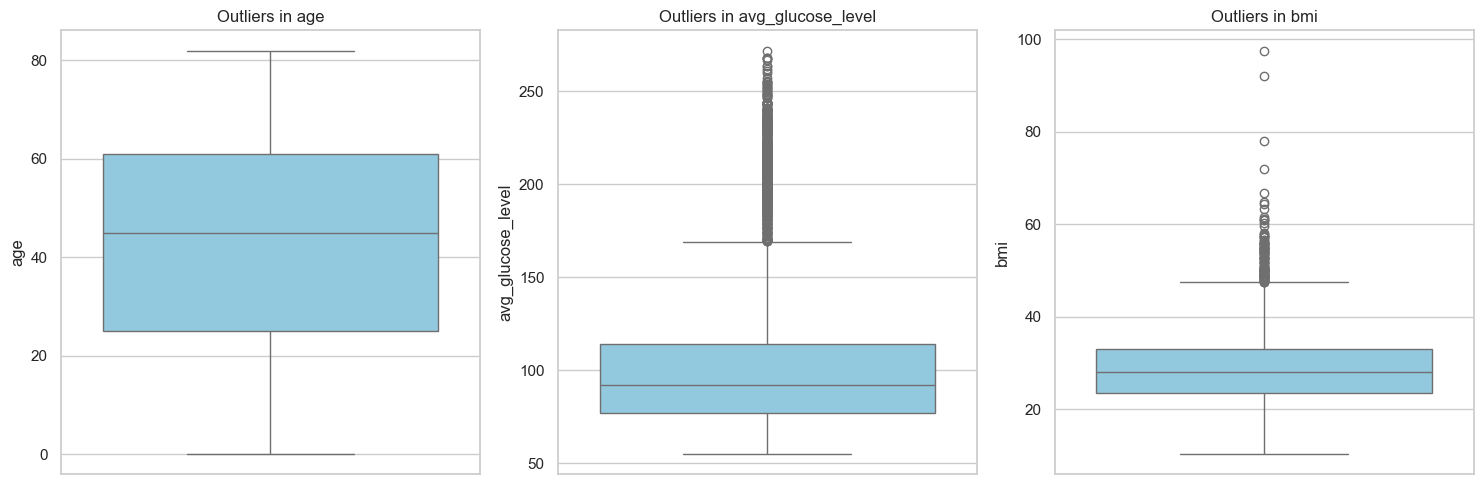

In [5]:
# ============================================================
# Cell 5: Outlier Detection (Boxplots)
# ============================================================
numerical_cols = ['age', 'avg_glucose_level', 'bmi']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

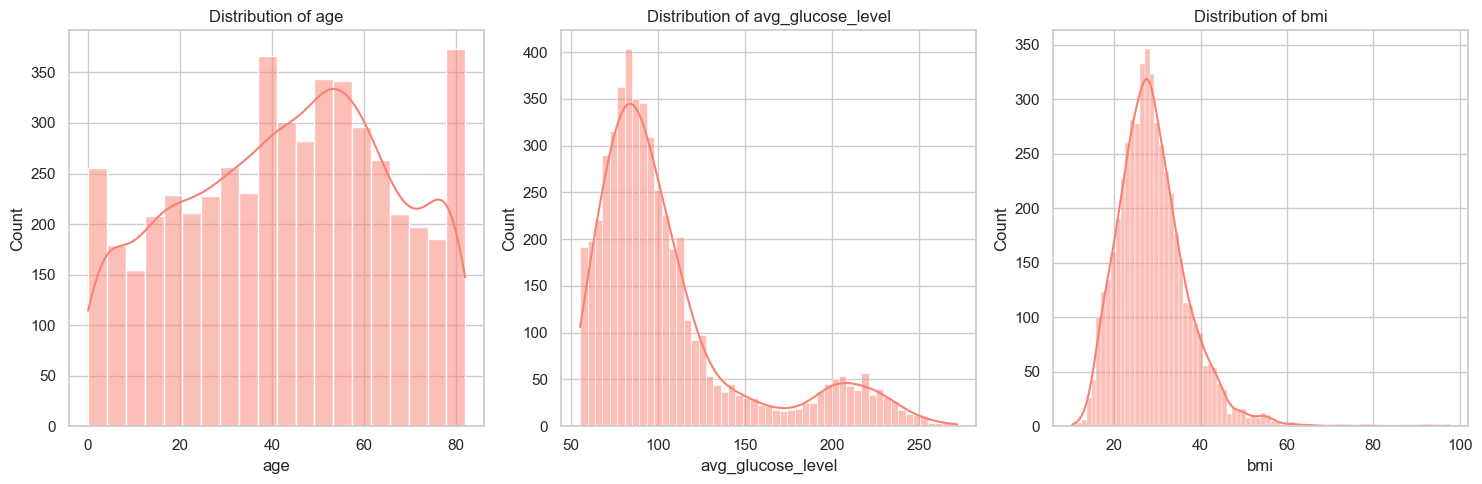

In [6]:
# ============================================================
# Cell 6: Distribution Trends (Histograms)
# ============================================================
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, color='salmon')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

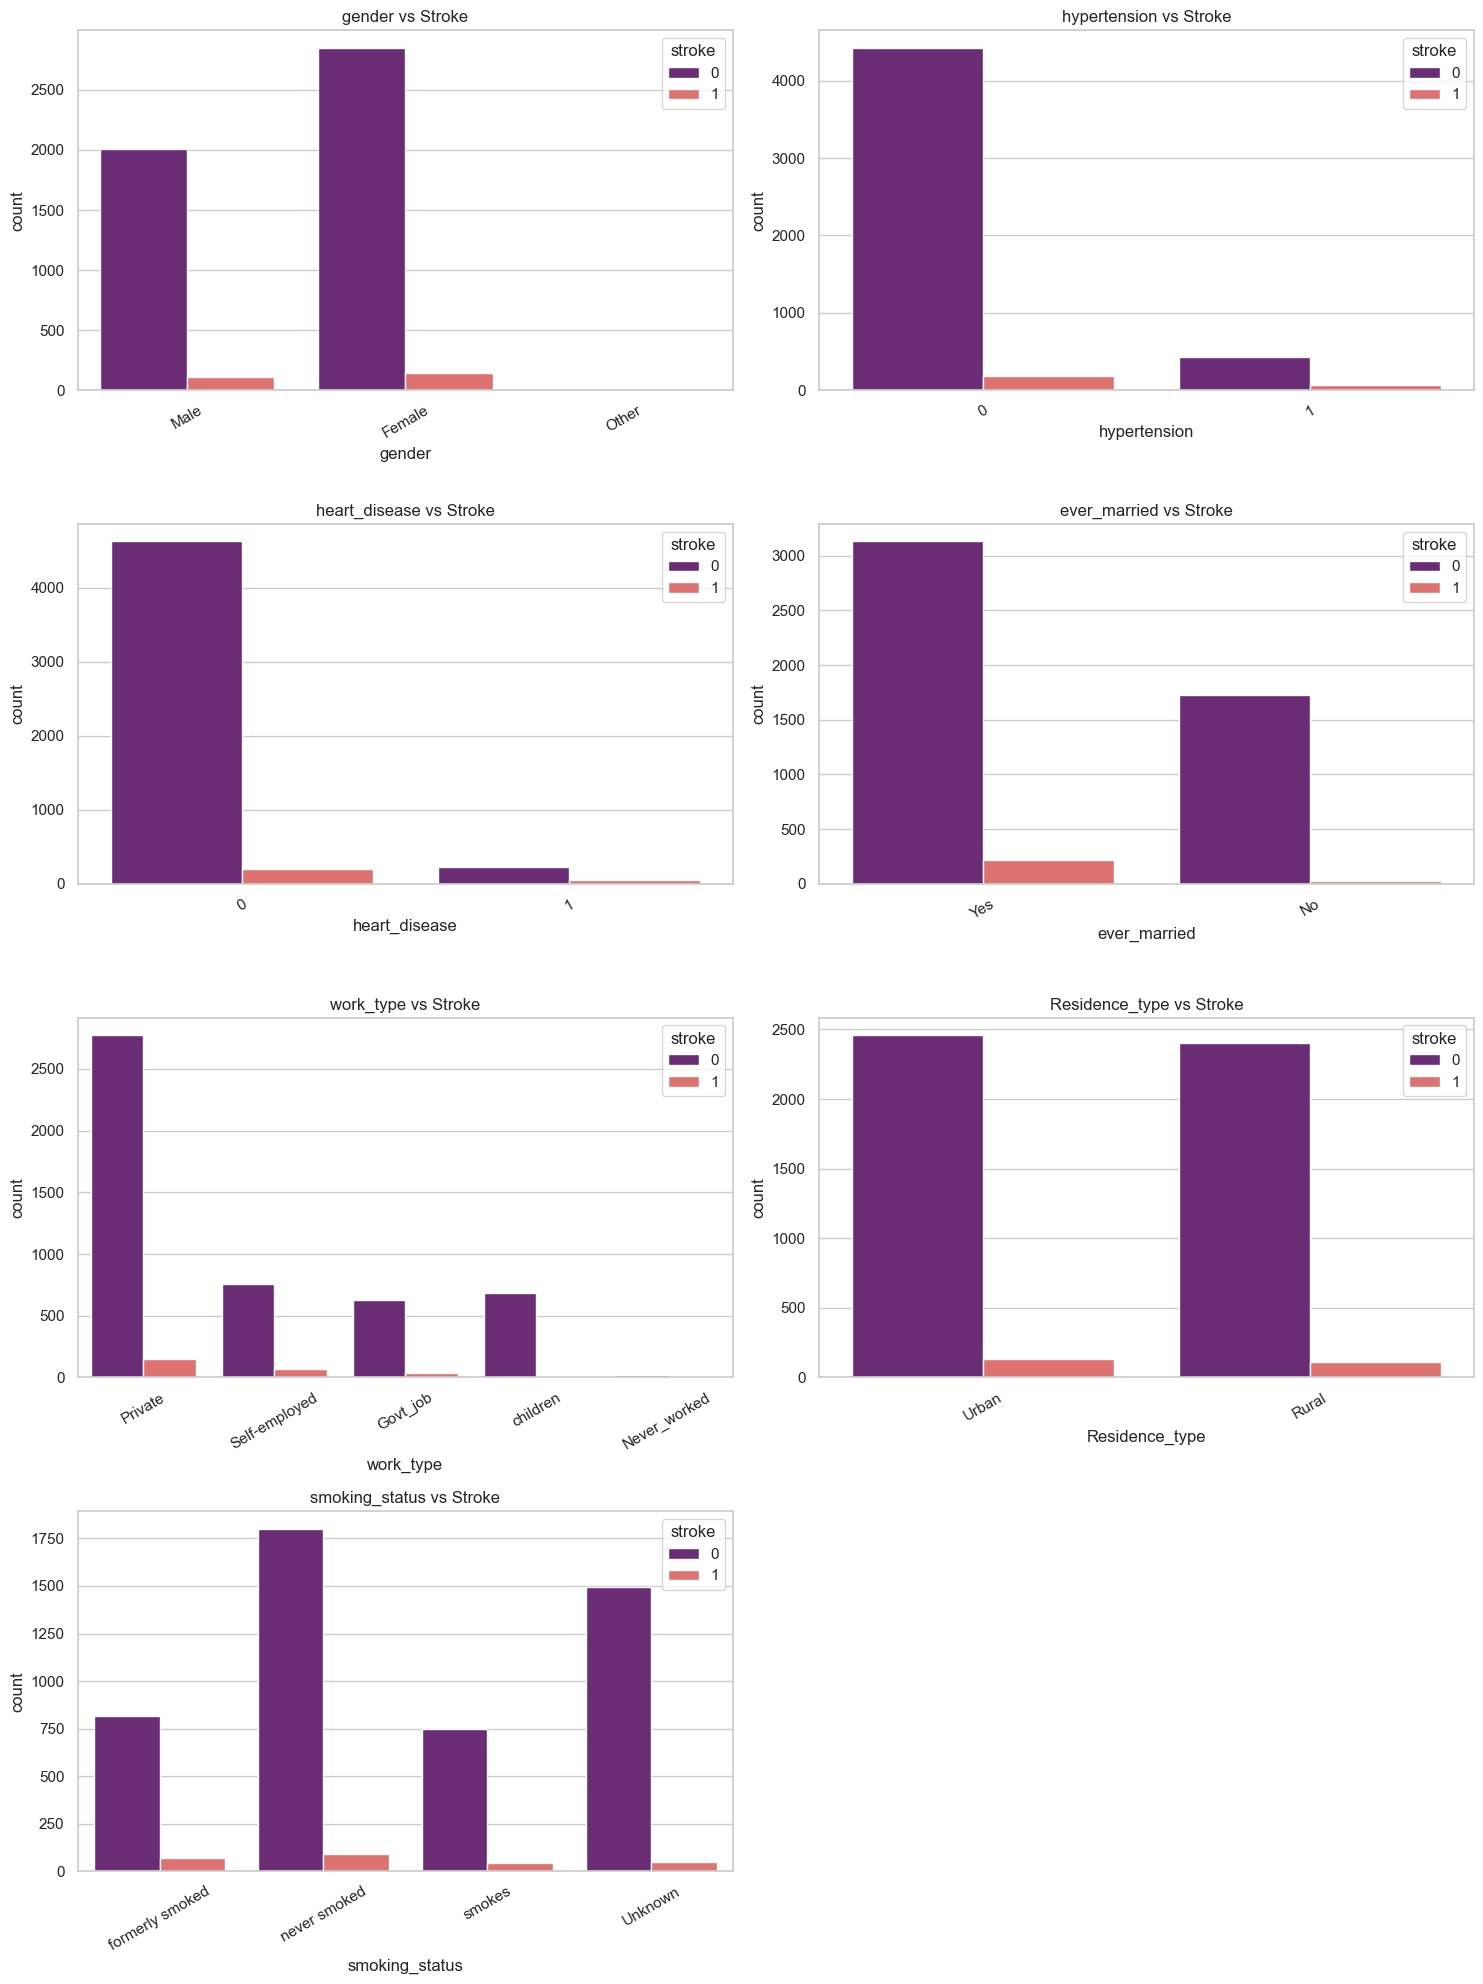

In [7]:
# ============================================================
# Cell 7: Categorical Features relative to Stroke
# ============================================================
cat_features = ['gender', 'hypertension', 'heart_disease', 'ever_married', 
                'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(x=col, hue='stroke', data=df, ax=axes[i], palette='magma')
    axes[i].set_title(f'{col} vs Stroke')
    axes[i].tick_params(axis='x', rotation=30)

# Delete the empty 8th subplot
fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

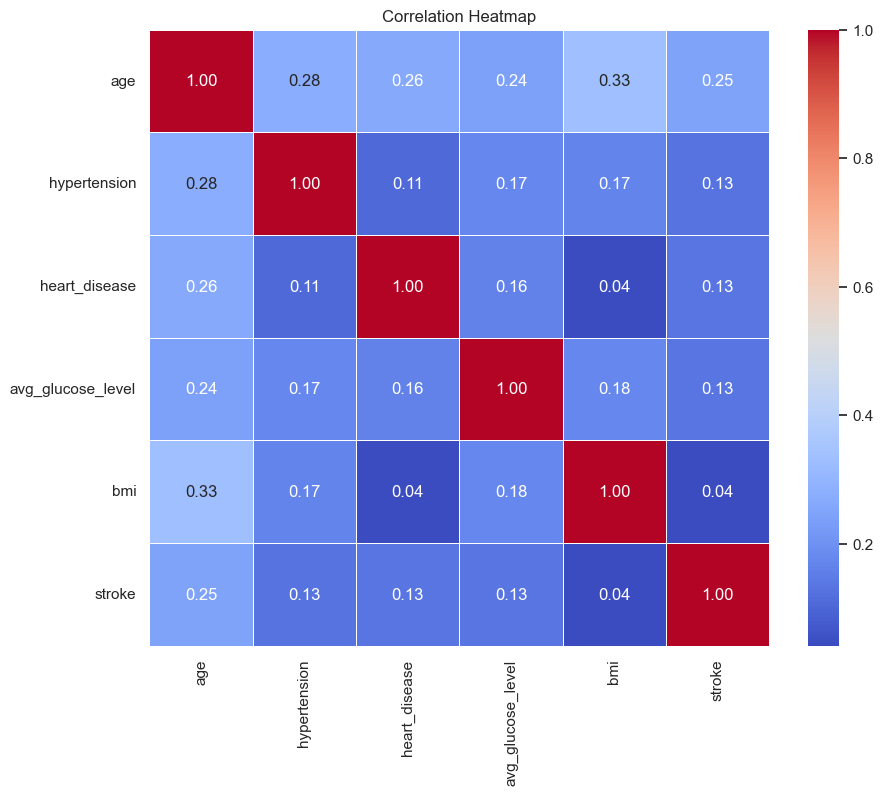

In [8]:
# ============================================================
# Cell 8: Numeric Feature Correlation Matrix
# ============================================================
plt.figure(figsize=(10, 8))

# Drop 'id' as it is a unique identifier with no predictive value
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['id'])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()